<a href="https://colab.research.google.com/github/claramanolache/ML_Intro/blob/main/Week_3_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Instructions

For this assignment, you will use the dataset loaded below (or another appropriate dataset of your choice) to perform the following steps that were demonstrated in the practice Notebook.

**Do not delete any instructor-provided cells from this Notebook.** If you accidentally delete a cell, you can either undo the action or load a copy of the original assignment Notebook in a new browser tab and copy over the missing cells.

**You can add cells to this Notebook.** To add a markdown (text) cell, hover your cursor beneath the cell where you want to insert and click the "+Text" button. To add a Python (code) cell, click the "+Code" button.

### Steps
- Inspect and display at least one image from the dataset
- Split the data into training and test sets
- Train a binary classifier
  - Create a binary label vector
  - Compare against a baseline dummy classifier
  - Evaluate accuracy using k-fold cross-validation
  - Report precision, recall, and F1 score
  - Display a confusion matrix
- Train a multiclass classifier
  - Fit the model and make predictions on the test set
  - Report your findings from the larger confusion matrix

## Import Libraries

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn import dummy
from sklearn import linear_model
from sklearn import metrics
from sklearn import model_selection

The following variable will be used to set a random seed for certain processes. Using a seed makes random processes deterministic, meaning this notebook will do things like split data the same way on each run. You are free to change this value to explore how the notebook runs differently.

In [12]:
seed = 42

## Load the Dataset

The [A-Z Handwritten Alphabets dataset](https://www.kaggle.com/datasets/sachinpatel21/az-handwritten-alphabets-in-csv-format) is a large-scale collection of grayscale images representing handwritten English capital letters. It contains over 370,000 samples, with each image sized at 28x28 pixels and centered for consistency. Each sample is labeled from A to Z.

To ease runtime, I have sampled 10% of this dataset and intentionally kept the classes in their original proportions.

In [13]:
df = pd.read_csv("https://raw.githubusercontent.com/dkauffman-foothill/course-datasets/refs/heads/main/ml/alphabet-images-sampled.csv", index_col=0)

Below, the feature matrix and label vector are separated as NumPy arrays. You do not need to modify this code.

In [14]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values
X.shape, y.shape

((37245, 784), (37245,))

## Inspect the Data

To verify the data was loaded correctly, choose an English uppercase character for the string below and proceed to get the index of its first occurrence in the label vector `y` (see the Practice Notebook for an example).

In [15]:
character = 'Y'  # Enter an uppercase character from A to Z in this string.



 Next, get the image data at that same index in `X` and store it in a variable called `char_image` (replacing `None` below). The code to display the image is already provided for you afterward.

In [16]:
char_index = np.where(y == character)[0][0]
char_image = X[char_index]
char_image

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         6,  75, 211, 167,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,  45, 170, 255, 198,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,  31,  10,   0,   0,   0,   0,   

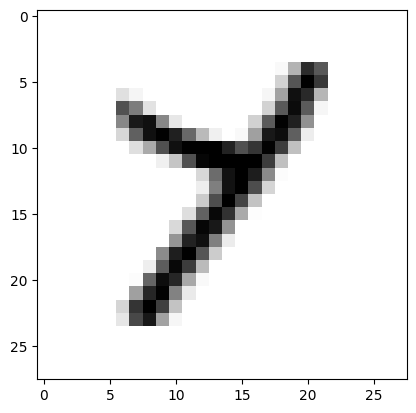

In [17]:
plt.imshow(char_image.reshape(28, 28), cmap="binary")  # You do not need to change this line.

## Prepare the Data

As this dataset is already clean, you only need to split it into training and test sets.

### Split the Data

Use `model_selection.train_test_split` to create training and test sets.

Optionally, you can set the `train_size` keyword to be a value from 0 to 1 indicating the size of the training set (e.g. a value of 0.8 means 80% of the data will be used for training). By default, scikit-learn uses a value of 0.75.

In [18]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

## Train a Binary Classifier

Before trying to make predictions for all characters, make a binary classifier that determines whether a sample is or is not the character you chose above.

### Create a Binary Label Vector
Create a vector of true/false values (as in the Practice Notebook) in which true corresponds to a row matching the character.

In [19]:
char_mask_y_train = (y_train == character)
char_mask_y_test = (y_test == character)

Checking if size changed

In [20]:
print("Binary Training and Testing labels size: ")
char_mask_y_train, char_mask_y_test
print("Original Training and Testing labels size: ")
y_train, y_test

Binary Training and Testing labels size: 
Original Training and Testing labels size: 


(array(['O', 'C', 'N', ..., 'C', 'O', 'C'], dtype=object),
 array(['B', 'S', 'R', ..., 'O', 'C', 'H'], dtype=object))

### Compare to a Baseline

Use a Dummy Classifier to get a baseline for this task. Instantiate and fit `dummy.DummyClassifier` to the binary label vector and use `model_selection.cross_val_score` with at least 3 validation folds.

In [21]:
dummy_clf = dummy.DummyClassifier()
dummy_clf.fit(X_train, char_mask_y_train)

DummyClassifier()

In [22]:
model_selection.cross_val_score(
  dummy_clf,
  X_train,
  char_mask_y_train,
  cv=5,
  scoring="accuracy"
)

array([0.97114094, 0.97130391, 0.9711361 , 0.9711361 , 0.9711361 ])

### Create a Real Classifier

Using your binary label vector, instantiate and fit a SGD classifier (or any scikit-learn classifier of your choice).

In [23]:
sgd_clf = linear_model.SGDClassifier(random_state=seed)
sgd_clf.fit(X_train, char_mask_y_train)

SGDClassifier(random_state=42)

### Evaluate Accuracy with K-Fold Cross-Validation

Use `model_selection.cross_val_score` to get accuracy scores across at least 3 validation folds.

In [24]:
model_selection.cross_val_score(
  sgd_clf,
  X_train,
  char_mask_y_train,
  cv=5,
  scoring="accuracy"
)

array([0.9852349 , 0.98338647, 0.98254741, 0.97835207, 0.98053365])

### Capture Precision, Recall, and F1 Score

Using scikit-learn's `metrics` subpackage, get the precision, recall, and f1 score of the SGD classifier's predictions.

In [25]:
metrics.precision_score(char_mask_y_train, sgd_clf.predict(X_train))

0.7513007284079084

In [26]:
metrics.recall_score(char_mask_y_train, sgd_clf.predict(X_train))

0.840512223515716

In [27]:
metrics.f1_score(char_mask_y_train, sgd_clf.predict(X_train))

0.7934065934065934

### Display a Confusion Matrix

Get a vector of predictions by calling `model_selection.cross_val_predict` using the features and binary label vector.

In [28]:
y_train_pred = model_selection.cross_val_predict(
    sgd_clf,
    X_train,
    char_mask_y_train,
    cv=5
)

With these predictions, call `metrics.ConfusionMatrixDisplay.from_predictions` with the binary label vector.

You may wish to set the following keyword arguments (though you can choose a different color scheme if you prefer):
- `cmap="Blues"`
- `colorbar=False`

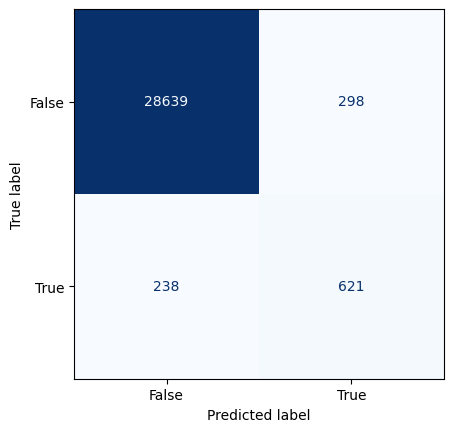

In [29]:
metrics.ConfusionMatrixDisplay.from_predictions(
    char_mask_y_train,
    y_train_pred,
    cmap="Blues",
    colorbar=False
)

### Report Findings

Based on the following:
- The accuracy of the dummy classifier
- The outcome of the real binary classifier
  - Accuracy
  - Precision, Recall, F1 score

What is your assessment of how well the real classifier performs? Is there one metric that reveals more than the others?


The dummy's best accuracy score is approximatly 97.1% while the real binary classifier has an accuracy of about 98.5% at best fold. While there is an improvement, it is not very significant, only 1.4% better. When evaluating closer, the lowest metric is the precision score of about 75.1%. This means the models struggles slightly with false positives. If approximatly 1 in every 4 positives it returns is actually false, we should not trust it's evaluation of y's very well. The recall is ok and the F1 score is slightly bad, which means that its good at classfing 'Y's. In total, the model is overlientant on classifying letters as Y's so it often mistakes letters for Y.This model definitely needs some work.

## Train a Multiclass Classifier

Using the original training label vector (not the binary label vector), instantiate and fit a SGD classifier (or another classifier of your choice) along with the training features.

In [30]:
sgd_MCC = linear_model.SGDClassifier(random_state=seed)
sgd_MCC.fit(X_train, y_train)

SGDClassifier(random_state=42)

Use the `predict` method for the classifier on the test features.

In [33]:
y_pred = sgd_MCC.predict(X_test)

### Display a Confusion Matrix

The code below is provided because of the need for additional keyword arguments that allow the entire matrix to display.

See the below matrix to report your findings.

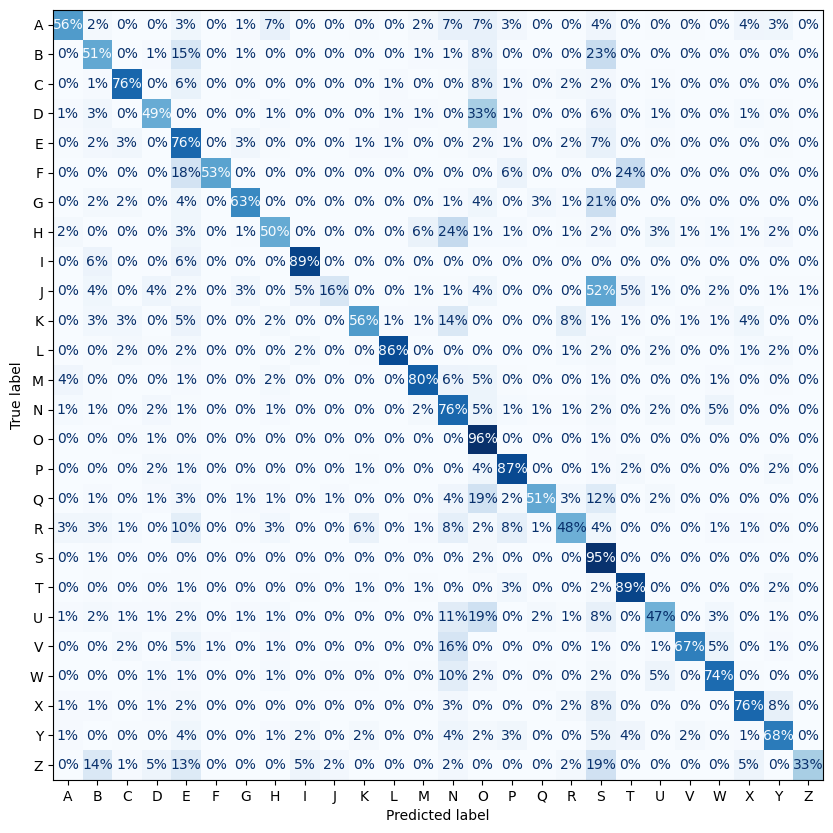

In [34]:
metrics.ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    normalize="true",
    values_format=".0%",
    cmap="Blues",
    colorbar=False,
    ax=plt.subplots(figsize=(10, 10))[1]
)

### Report Findings

Based on the confusion matrix, where does it appear the classifier had the most difficulty? What characters did it confuse the most? Does it align with your expectations? Why or why not?

The multiclass classifier had difficulty with the letter Z—detecting it correctly only 33% and mistaking it most often with S 19% of the time, E 13% of the time, and B 14%. It also sometimes (< 5% of the time) got Z confused with R, N, J, X, I, C and D. The errors under 5% are likely due to random noise, as most of the other letters had error's spread out below 5%. However, for the main ones it classified, there was structural simmimlarity as there are three lines in the middle. This means that the model needs to be more generalized because it is weighing that one specific structural feature too heavily. But it is understandable why it made this mistake, sometimes I get those letters confused with my handwriting.

The classifier had the most diffulty with J at 16%, confusing it with S 52% of the time! I did not expect S to be confused with J so often. I would understand confusing I and J as the top half is very simmilar but this only 5% of the time. It may be the curvature that triggered the S classification, but it is hard to determine where this mistake occucured, as the J classifier didn't have much issue with U or G (both under 5%).

Some understandable mistakes are confusing H with N(24%), D with O (33%), G with S (21%), B with S (23%), and F with T (24%) as they all have some common structure.

---

Optionally, you may find it helpful to display more images below for the characters that the model got confused. I have copied the `plt.imshow` function call below; replace `None` with one of the images from `X_test` to display that image.

Recall that you can get the index of a specific character in `y_test` by using the `np.where` function (see the Practice Notebook) and then indexing at that same location in `X_test`.

In [35]:
char_image = None
plt.imshow(char_image.reshape(28, 28), cmap="binary")

AttributeError: 'NoneType' object has no attribute 'reshape'